In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
# data loading
df = pd.read_csv('API_NY.GDP.MKTP.CD_DS2_en_csv_v2_446954.csv',skiprows=4)
india = df[df['Country Name'] == 'India']
print(india.shape)
print(india.head())

(1, 71)
    Country Name Country Code     Indicator Name  Indicator Code  \
109        India          IND  GDP (current US$)  NY.GDP.MKTP.CD   

             1960          1961          1962          1963          1964  \
109  3.702988e+10  3.923244e+10  4.216148e+10  4.842192e+10  5.648029e+10   

             1965  ...          2017          2018          2019  \
109  5.955611e+10  ...  2.651474e+12  2.702930e+12  2.835606e+12   

             2020          2021          2022          2023          2024  \
109  2.674852e+12  3.167271e+12  3.346107e+12  3.638489e+12  3.909892e+12   

     2025  Unnamed: 70  
109   NaN          NaN  

[1 rows x 71 columns]


In [3]:
years = [str(year) for year in range(1960,2024)]
print(years[:5])
print(years[-5:])

#only for india 
india_gdp = india[years]
print(india_gdp.shape)
print(india_gdp.head())

['1960', '1961', '1962', '1963', '1964']
['2019', '2020', '2021', '2022', '2023']
(1, 64)
             1960          1961          1962          1963          1964  \
109  3.702988e+10  3.923244e+10  4.216148e+10  4.842192e+10  5.648029e+10   

             1965          1966          1967          1968          1969  \
109  5.955611e+10  4.558123e+10  5.013494e+10  5.308546e+10  5.844800e+10   

     ...          2014          2015          2016          2017  \
109  ...  2.039126e+12  2.103588e+12  2.294797e+12  2.651474e+12   

             2018          2019          2020          2021          2022  \
109  2.702930e+12  2.835606e+12  2.674852e+12  3.167271e+12  3.346107e+12   

             2023  
109  3.638489e+12  

[1 rows x 64 columns]


In [4]:
#for transpose
india_gdp = india_gdp.T
print(india_gdp.head())
print(india_gdp.shape)

               109
1960  3.702988e+10
1961  3.923244e+10
1962  4.216148e+10
1963  4.842192e+10
1964  5.648029e+10
(64, 1)


In [5]:
#column name set
india_gdp.columns = ['GDP']

#changing tears as int
india_gdp.index = india_gdp.index.astype(int)

#to change gdp as numeric
india_gdp['GDP'] = pd.to_numeric(india_gdp['GDP'],errors = 'coerce')

print(india_gdp.dtypes)
print(india_gdp.head())

GDP    float64
dtype: object
               GDP
1960  3.702988e+10
1961  3.923244e+10
1962  4.216148e+10
1963  4.842192e+10
1964  5.648029e+10


In [6]:
# to convert gdp in billions
india_gdp['GDP_Billion'] = india_gdp['GDP'] / 1e9

print(india_gdp.head())
print(india_gdp.tail())

               GDP  GDP_Billion
1960  3.702988e+10    37.029884
1961  3.923244e+10    39.232436
1962  4.216148e+10    42.161482
1963  4.842192e+10    48.421923
1964  5.648029e+10    56.480290
               GDP  GDP_Billion
2019  2.835606e+12  2835.606257
2020  2.674852e+12  2674.851579
2021  3.167271e+12  3167.270623
2022  3.346107e+12  3346.107288
2023  3.638489e+12  3638.489096


In [7]:
# calculation of groth rate
india_gdp['Growth_Rate'] = india_gdp['GDP_Billion'].pct_change() * 100

print(india_gdp.head(10))
print(india_gdp.tail(20))

               GDP  GDP_Billion  Growth_Rate
1960  3.702988e+10    37.029884          NaN
1961  3.923244e+10    39.232436     5.948039
1962  4.216148e+10    42.161482     7.465879
1963  4.842192e+10    48.421923    14.848723
1964  5.648029e+10    56.480290    16.641979
1965  5.955611e+10    59.556105     5.445821
1966  4.558123e+10    45.581231   -23.465058
1967  5.013494e+10    50.134942     9.990322
1968  5.308546e+10    53.085456     5.885144
1969  5.844800e+10    58.447995    10.101711
               GDP  GDP_Billion  Growth_Rate
2004  7.091527e+11   709.152729    16.694410
2005  8.203838e+11   820.383764    15.685061
2006  9.402599e+11   940.259889    14.612201
2007  1.216736e+12  1216.736439    29.404269
2008  1.198895e+12  1198.895139    -1.466324
2009  1.341888e+12  1341.888017    11.927055
2010  1.675616e+12  1675.615519    24.869996
2011  1.823052e+12  1823.051830     8.798934
2012  1.827638e+12  1827.637590     0.251543
2013  1.856722e+12  1856.721508     1.591339
2014  2.03

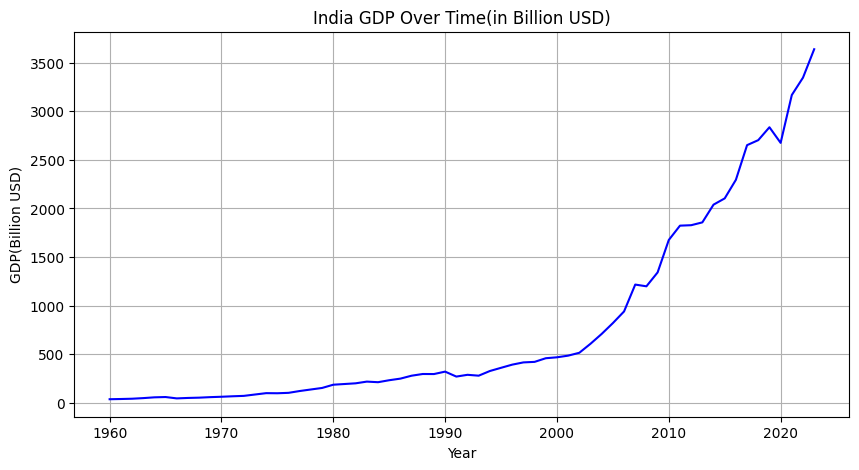

In [8]:
# GDP line chart of yearly growth
plt.figure(figsize=(10,5))
plt.plot(india_gdp.index,india_gdp['GDP_Billion'],color='blue')
plt.title('India GDP Over Time(in Billion USD)')
plt.xlabel('Year')
plt.ylabel('GDP(Billion USD)')
plt.grid(True)
plt.show()

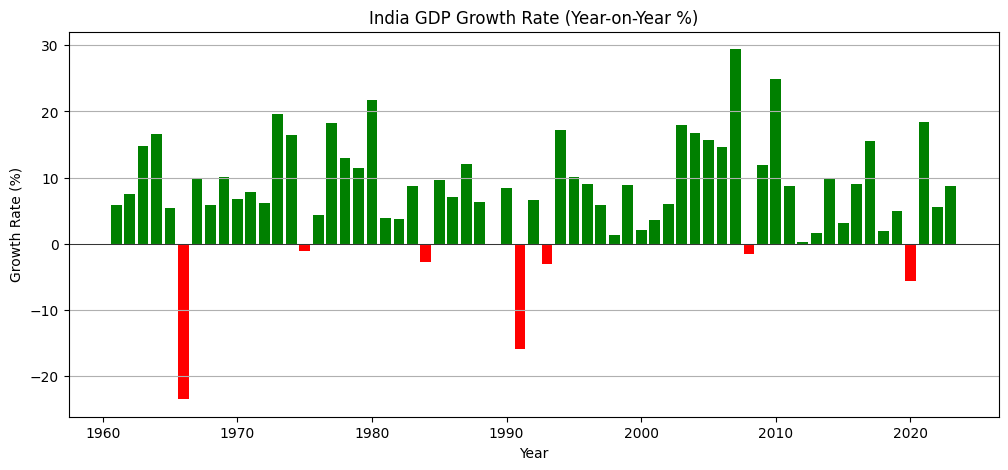

In [9]:
# bar chart of yearly growth
plt.figure(figsize = (12,5))
colors = ['green' if x>= 0 else 'red' for x in india_gdp['Growth_Rate']]
plt.bar(india_gdp.index, india_gdp['Growth_Rate'], color=colors)
plt.axhline(0,color='black',linewidth = 0.5)
plt.title('India GDP Growth Rate (Year-on-Year %)')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.grid(True,axis ='y')
plt.show()

In [10]:
# key statistics
avg_growth = india_gdp['Growth_Rate'].mean()
best_year = india_gdp['Growth_Rate'].idxmax()
best_value = india_gdp['Growth_Rate'].max()
worst_year = india_gdp['Growth_Rate'].idxmin()
worst_value = india_gdp['Growth_Rate'].min()

print(f"Average Growth Rate : {avg_growth: .2f}%")
print(f"Best Year: {best_year}({best_value: .2f}%)")
print(f"worst Year: {worst_year}({worst_value: .2f}%)")

Average Growth Rate :  7.91%
Best Year: 2007( 29.40%)
worst Year: 1966(-23.47%)


In [11]:
# Compound Annual Growth Rate (CAGR) calculation
start_value = india_gdp['GDP_Billion'].iloc[0]
end_value = india_gdp['GDP_Billion'].iloc[-1]
num_years = india_gdp.index[-1] - india_gdp.index[0]

cagr = ((end_value/start_value)**(1/num_years)-1)*100

print(f"Start Year GDP ({india_gdp.index[0]}):{start_value:.2f} Billion USD")
print(f"End Year GDP ({india_gdp.index[-1]}):{end_value:.2f} Billion USD")
print(f"CARG over {num_years} years: {cagr:.2f}%")

Start Year GDP (1960):37.03 Billion USD
End Year GDP (2023):3638.49 Billion USD
CARG over 63 years: 7.55%


In [12]:
# Decade Wise Average Growth
india_gdp['Decade'] = (india_gdp.index // 10)*10
decade_growth = india_gdp.groupby('Decade')['Growth_Rate'].mean()

print(decade_growth)

Decade
1960     5.873618
1970    10.282132
1980     7.016422
1990     4.855823
2000    11.667320
2010     7.997886
2020     6.781107
Name: Growth_Rate, dtype: float64


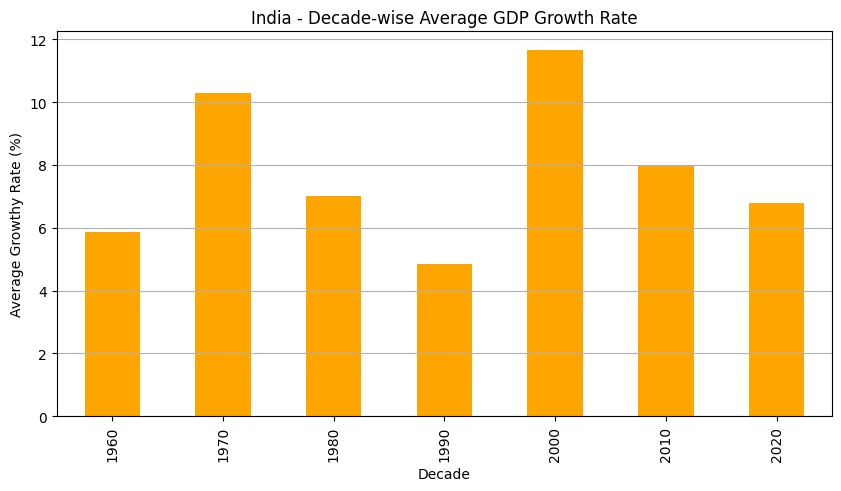

In [13]:
# Decade-wise bar chart 
plt.figure(figsize=(10,5))
decade_growth.plot(kind='bar', color ='orange')
plt.title('India - Decade-wise Average GDP Growth Rate')
plt.xlabel('Decade')
plt.ylabel('Average Growthy Rate (%)')
plt.grid(True,axis='y')
plt.show()

In [14]:
# Volatility(standard Deviation)
volatility = india_gdp['Growth_Rate'].std()

print(f"Volatility(Std Dev) of Growth Rate:{volatility:.2f}%")

Volatility(Std Dev) of Growth Rate:8.58%


In [15]:
# For future forcasting 

years = india_gdp.index.values
gdp_values = india_gdp['GDP_Billion'].values

# Quadratic curve fit (trend line)
coeffs = np.polyfit(years, gdp_values, 2)
trend = np.poly1d(coeffs)

future_years = np.arange(years[-1]+1, years[-1]+6)
future_gdp = trend(future_years)

for y, g in zip(future_years, future_gdp):
    print(f"{y}: {g:.2f} Billion USD (estimated)")

2024: 3356.74 Billion USD (estimated)
2025: 3503.96 Billion USD (estimated)
2026: 3654.27 Billion USD (estimated)
2027: 3807.68 Billion USD (estimated)
2028: 3964.19 Billion USD (estimated)


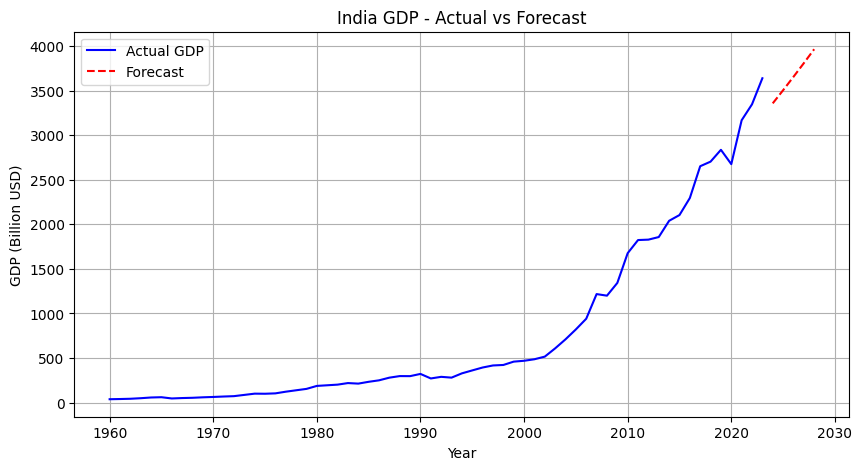

In [16]:
# future forcast trendline 
plt.figure(figsize=(10,5))
plt.plot(years, gdp_values, label='Actual GDP', color='blue')
plt.plot(future_years, future_gdp, label='Forecast', color='red', linestyle='--')
plt.title('India GDP - Actual vs Forecast')
plt.xlabel('Year')
plt.ylabel('GDP (Billion USD)')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
## Conclusion
- India's GDP grew from **$37.03 Billion (1960)** to **3638.49 Billion(2023)**.
- The average year-on-year growth rate was approximately **7.91%**.
- The **CAGR** over 63 years was **7.55%**,showing strong long-term compounding growth.
- The best-performing year was **2007** with growth of **29.40%**, while the worst was **1966** with **-23.47%**.
- Decade-wise, growth was strong during the **2000** period, reflecting economic reforms and libralization.
- The volatility (std dev) of **8.58%** indicates moderately volatile growth over the decades.

SyntaxError: unterminated string literal (detected at line 2) (1957517493.py, line 2)